### 1. Подключаем все необходимые библиотеки

In [ ]:
!pip install tensorflow

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Input

### 2. Загрузка и подготовка данных

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Нормализация данных (значения от 0 до 1)

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

One-hot encoding для меток

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

### 3. Построение модели

In [7]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

### 4. Компиляция модели

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### 5. Обучение модели

In [9]:
history = model.fit(x_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8629 - loss: 0.4802 - val_accuracy: 0.9603 - val_loss: 0.1375
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9639 - loss: 0.1200 - val_accuracy: 0.9666 - val_loss: 0.1120
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9760 - loss: 0.0766 - val_accuracy: 0.9702 - val_loss: 0.1054
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9831 - loss: 0.0553 - val_accuracy: 0.9674 - val_loss: 0.1107
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9870 - loss: 0.0427 - val_accuracy: 0.9718 - val_loss: 0.0991


### 6. Оценка модели

In [10]:
loss, accuracy = model.evaluate(x_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0994
Test accuracy: 0.9763


### 7. Графики точности и потерь

In [11]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Точность

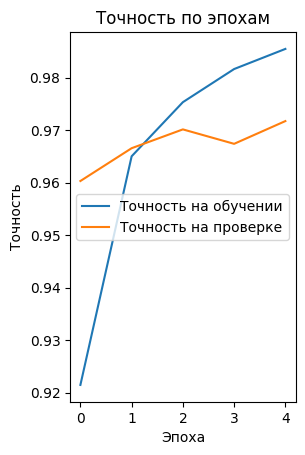

In [12]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на проверке')
plt.title('Точность по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

Потери

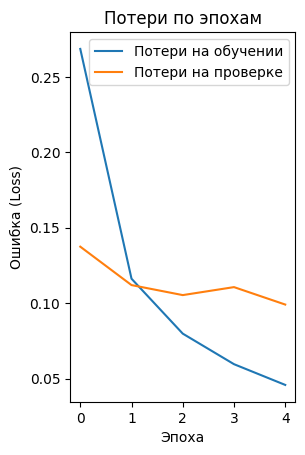

In [13]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на проверке')
plt.title('Потери по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка (Loss)')
plt.legend()

### 8. Предсказания на тестовой выборке

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


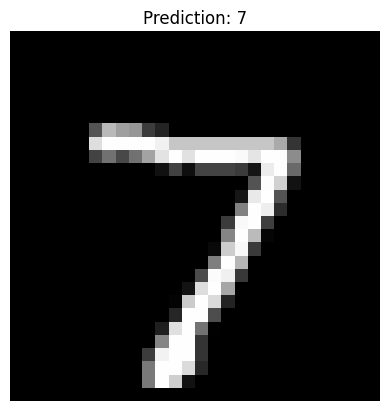

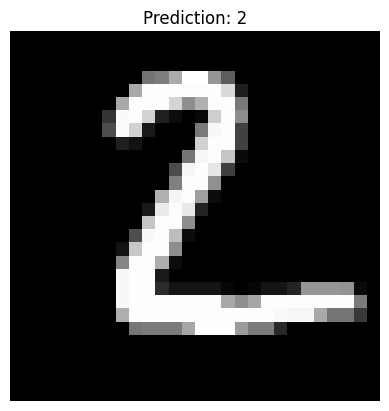

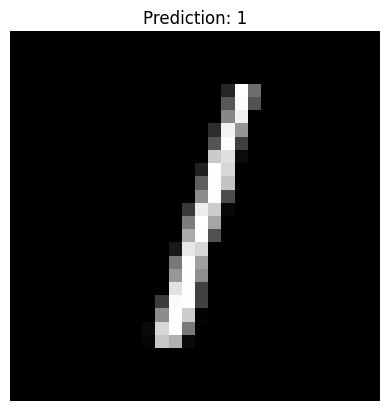

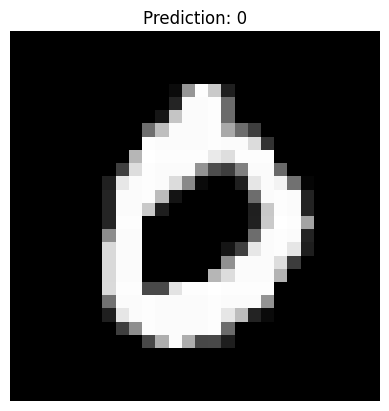

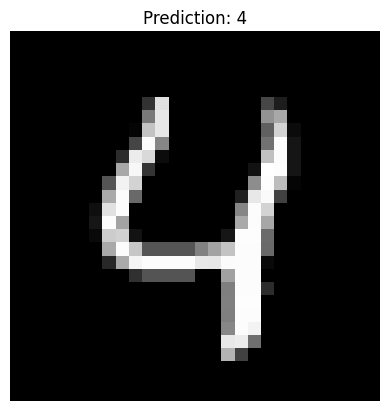

In [14]:
predictions = model.predict(x_test)

for i in range(5):
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Prediction: {np.argmax(predictions[i])}")
    plt.axis('off')
    plt.show()

### 9. Проверка на своей цифре (через рисование)

➡️ Нарисуй цифру (на 28x28 холсте в Paint/другое) и загрузи сюда (формат PNG/JPG)


Saving 5.png to 5.png


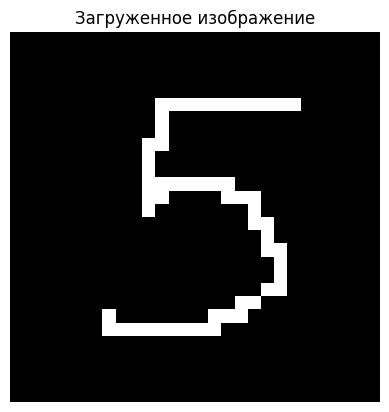

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
🔍 Распознанная цифра: 5


In [16]:
from PIL import Image
import cv2
from google.colab import widgets, files
import io

print("➡️ Нарисуй цифру (на 28x28 холсте в Paint/другое) и загрузи сюда (формат PNG/JPG)")

uploaded = files.upload()

for filename in uploaded.keys():
    # Загрузка изображения
    image = Image.open(io.BytesIO(uploaded[filename])).convert('L')  # Ч/б
    image = image.resize((28, 28))  # Изменение размера
    image_array = np.array(image)

    # Инверсия, если нужно (фон — чёрный, цифра — белая)
    if np.mean(image_array) > 127:
        image_array = 255 - image_array

    # Нормализация
    image_array = image_array / 255.0

    # Отображение изображения
    plt.imshow(image_array, cmap='gray')
    plt.title("Загруженное изображение")
    plt.axis('off')
    plt.show()

    # Предсказание
    input_image = image_array.reshape(1, 28, 28)
    prediction = model.predict(input_image)
    predicted_label = np.argmax(prediction)
    print(f"🔍 Распознанная цифра: {predicted_label}")